In [1]:
%load_ext autoreload
%autoreload 2

# Reach grid with joint limits

Same grid as `reach-grid.ipynb`, optionally gated by the config's joint limits and by
the body box (`robot.mount_box`): a vertex whose foot lies inside the box is dropped.
Only the foot point is tested, not the links. Everything is in the shoulder frame
(shoulder at the origin); the body is placed as if this were the right front leg.

In [2]:
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from controlkit.se3 import SE3
from controlkit.kinematics import Leg3DOF, Robot, candidates, radial_mounts
import controlkit.rerun_viz as rrv

from lab.gait_graph.planner.climb_model.config import MjModelCfg

In [3]:
# Shoulder at the origin. cfg only seeds the parameters; override them freely.
cfg = MjModelCfg()

LENGTHS = jnp.asarray(cfg.leg_lengths)                               # coxa, femur, tibia (m)
# LIMITS = jnp.deg2rad(jnp.asarray(cfg.joint_limits_deg, dtype=float)) # (3, 2) rad
LIMITS = jnp.deg2rad(jnp.array([[-90,90],[-100,100], [-160,160]]))
leg = Leg3DOF.from_lengths(LENGTHS, LIMITS)
reach = float(LENGTHS.sum())                                         # grid half-width (m)

USE_LIMITS = True    # gate branches by LIMITS
FILTER_BODY = True   # drop vertices whose foot lies inside the body box

print("lengths:", LENGTHS, " reach:", reach)
print("limits (deg):", np.rad2deg(np.asarray(LIMITS)).round().tolist())

lengths: [0.05 0.15 0.2 ]  reach: 0.4000000059604645
limits (deg): [[-90.0, 90.0], [-100.0, 100.0], [-160.0, 160.0]]


In [4]:
# Body, placed relative to the shoulder. Mounts at 45, 135, 225, 315 deg
# (+x forward, +y left): right front is 315 deg.
mounts = radial_mounts(cfg.num_legs, radius=cfg.mount_radius)
LEG = 3
body = mounts[LEG].inverse()                       # body pose in the shoulder frame
body_center, body_half = Robot(mounts=mounts, leg=leg).mount_box(
    half_height=cfg.body_half_height)              # box in the body frame

print("body centre (shoulder frame):", body.apply(body_center))
print("body yaw (deg):", np.rad2deg(float(body.rotation().compute_yaw_radians())))

body centre (shoulder frame): [-1.000000e-01 -4.361237e-08  0.000000e+00]
body yaw (deg): 45.00003198809035


## Grid

In [5]:
RES = 0.01   # voxel size (m)

n = int(round(2 * reach / RES)) + 1
axis = jnp.linspace(-reach, reach, n)
X, Y, Z = jnp.meshgrid(axis, axis, axis, indexing="ij")
verts = jnp.stack([X, Y, Z], axis=-1).reshape(-1, 3)        # (n^3, 3), shoulder frame
print(f"{n}^3 = {verts.shape[0]:,} vertices")

81^3 = 531,441 vertices


## IK over the grid

`ok_ik`: a branch exists. `ok`: it also passes the enabled filters (limits, body box).

In [6]:
def _reach_vertex(foot):
    ok_ik, thetas = leg.ik_from_foot(foot)                 # (4,), (4, 3)
    ok = ok_ik
    if USE_LIMITS:
        ok = ok & candidates.in_limits(thetas, leg.limits)
    if FILTER_BODY:
        in_body = jnp.all(jnp.abs(body.inverse().apply(foot) - body_center) <= body_half)
        ok = ok & ~in_body
    xpos = jax.vmap(leg.forward)(thetas).translation()     # (4, n+1, 3)
    knee_to_foot = xpos[:, -1] - xpos[:, -2]               # (4, 3)
    return ok_ik, ok, thetas, knee_to_foot

reach_grid = jax.jit(jax.vmap(_reach_vertex))

t0 = time.perf_counter(); out = jax.block_until_ready(reach_grid(verts)); t1 = time.perf_counter()
out = jax.block_until_ready(reach_grid(verts)); t2 = time.perf_counter()
print(f"compile+run: {t1 - t0:.2f}s   run: {(t2 - t1) * 1e3:.1f}ms")

ok_ik, ok, thetas, knee_to_foot = out

compile+run: 0.59s   run: 277.7ms


In [7]:
N = verts.shape[0]
n_branches_ik = np.asarray(ok_ik.sum(-1))
n_branches = np.asarray(ok.sum(-1))   # IK branches passing the filters, per vertex

print(f"USE_LIMITS={USE_LIMITS}  FILTER_BODY={FILTER_BODY}")
print(f"reachable (IK only):  {(n_branches_ik > 0).sum():,} / {N:,}")
print(f"reachable (filtered): {(n_branches > 0).sum():,} / {N:,}")
print("branches per vertex (filtered):", {int(k): int(v) for k, v in zip(*np.unique(n_branches, return_counts=True))})
print("vertices per branch (filtered):", np.asarray(ok.sum(0)), " (yaw-major, elbow-down first)")

USE_LIMITS=True  FILTER_BODY=True
reachable (IK only):  245,305 / 531,441
reachable (filtered): 143,424 / 531,441
branches per vertex (filtered): {0: 388017, 1: 60551, 2: 82873}
vertices per branch (filtered): [101799 101799  11235  11464]  (yaw-major, elbow-down first)


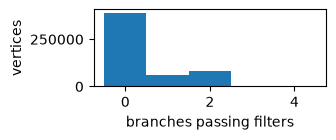

In [8]:
plt.figure(figsize=(3,1))
plt.hist(n_branches, bins=np.arange(6) - 0.5)
plt.xlabel("branches passing filters"); plt.ylabel("vertices");

## Rerun

Shoulder frame; the body box is rotated by the body's yaw.

In [139]:
rrv.init_viewer(connect=8812)
rrv.set_time(0, timeline="t")

verts_np = np.asarray(verts)
keep = n_branches > 0
excluded = (n_branches_ik > 0) & ~keep   # IK-reachable, removed by limits / body box

rrv.log_points("grid/reachable", verts_np[keep], values=n_branches[keep], radius=0.003)
rrv.log_points("grid/excluded", verts_np[excluded], radius=0.0015, color=(230, 120, 120))

rrv.log_box("body", body.apply(body_center), body_half,
            quaternion=np.roll(np.asarray(body.rotation().wxyz), -1),   # wxyz -> xyzw
            color=(60, 60, 60))

2026-10-08T17:40:52.530824Z ERROR re_grpc_client::write: Write messages call failed: transport error


In [110]:
# All branches passing the filters at one vertex (shoulder-frame target).
SHOULDER = SE3.from_te(jnp.zeros(3), jnp.zeros(3))
target = jnp.array([0.25, 0.0, -0.15])
i = int(jnp.argmin(jnp.linalg.norm(verts - target, axis=-1)))
print("vertex", verts[i], " ok_ik", ok_ik[i], " ok", ok[i])
for j in range(4):
    if ok[i, j]:
        rrv.log_leg(f"legs/b{j}", leg, SHOULDER, thetas[i, j])

vertex [ 2.4000002e-01  1.1175871e-08 -1.6000000e-01]  ok_ik [ True  True  True  True]  ok [ True False False False]


## Signed distance

$d(p) > 0$ reachable (after the filters), $d(p) < 0$ not, in metres, shoulder frame. From the
vertex mask by Euclidean distance transforms, padded with unreachable cells so the reach set
sits away from the grid edge. Tricubic Catmull-Rom interpolation (C1, passes through the
vertex values); gradients by autodiff, so they are the interpolant's true derivative.
Outside the padded grid: clamp, then subtract the distance to the clamp point (continuous,
kink at the grid edge).

Caveat: the transform measures distance between voxel centres, so the zero level sits
between the last reachable and the first unreachable vertex (error up to ~h/2), and
|grad d| is only approximately 1. Boundary vertices are shifted to +-h/2 so the slope across
the boundary is 1.

In [9]:
from scipy.ndimage import distance_transform_edt

PAD = 4                                   # cells of unreachable padding per side
h = float(axis[1] - axis[0])              # grid spacing (m)

mask = np.pad((n_branches > 0).reshape(n, n, n), PAD)                      # False = unreachable
# Shift by half a cell so the boundary vertices sit at +-h/2 (slope 1 across the boundary).
D = np.where(mask, distance_transform_edt(mask) - 0.5, -(distance_transform_edt(~mask) - 0.5)) * h
D = jnp.asarray(D, jnp.float32)
m = D.shape[0]
lo = float(axis[0]) - PAD * h             # coordinate of index 0, every axis

print(f"sdf grid {D.shape}  {D.nbytes / 1e6:.1f} MB  range [{float(D.min()):.3f}, {float(D.max()):.3f}] m")

sdf grid (89, 89, 89)  2.8 MB  range [-0.496, 0.135] m


In [10]:
def _cr_weights(t):
    # Catmull-Rom weights for the samples at offsets -1, 0, 1, 2; t in [0, 1).
    t2, t3 = t * t, t * t * t
    return 0.5 * jnp.stack([-t3 + 2 * t2 - t, 3 * t3 - 5 * t2 + 2, -3 * t3 + 4 * t2 + t, t3 - t2])

def _sdf_in_grid(p):
    u = (p - lo) / h                                   # continuous index
    i = jnp.floor(u).astype(jnp.int32)
    t = u - i
    idx = i[:, None] + jnp.arange(-1, 3)               # (3, 4) stencil indices
    patch = D[idx[0][:, None, None], idx[1][None, :, None], idx[2][None, None, :]]   # (4, 4, 4)
    return jnp.einsum("ijk,i,j,k->", patch, _cr_weights(t[0]), _cr_weights(t[1]), _cr_weights(t[2]))

def sdf(p):
    # Signed distance to the reach set (m), shoulder frame; > 0 reachable.
    q = jnp.clip(p, lo + h, lo + (m - 3) * h)          # where the 4x4x4 stencil fits
    dq = p - q
    return _sdf_in_grid(q) - jnp.sqrt(jnp.maximum(dq @ dq, 1e-20))   # safe norm: grad 0 at dq = 0

_sdf_vg = jax.jit(jax.vmap(jax.value_and_grad(sdf)))

def sdf_vg(P, chunk=1 << 18):
    # Value and gradient at (N, 3) points, in chunks to bound memory.
    out = [_sdf_vg(P[k:k + chunk]) for k in range(0, P.shape[0], chunk)]
    return jnp.concatenate([o[0] for o in out]), jnp.concatenate([o[1] for o in out])

t0 = time.perf_counter(); d_v, g_v = jax.block_until_ready(sdf_vg(verts)); t1 = time.perf_counter()
d_v, g_v = jax.block_until_ready(sdf_vg(verts)); t2 = time.perf_counter()
print(f"value+grad at {N:,} vertices   compile+run: {t1 - t0:.2f}s   run: {t2 - t1:.2f}s")

value+grad at 531,441 vertices   compile+run: 0.28s   run: 0.02s


In [11]:
# 1. Sign agrees with the mask at the vertices (Catmull-Rom interpolates the samples).
keep = n_branches > 0
print(f"sign mismatches at vertices: {int(((np.asarray(d_v) > 0) != keep).sum())} / {N:,}")

# 2. Autodiff gradient vs central finite differences, random points incl. outside the grid.
P = jax.random.uniform(jax.random.PRNGKey(0), (2000, 3), minval=-reach - 0.1, maxval=reach + 0.1)
_, g = sdf_vg(P)
eps = 1e-4   # well below h, so few central differences straddle a cell boundary
fd = jnp.stack([(sdf_vg(P + eps * e)[0] - sdf_vg(P - eps * e)[0]) / (2 * eps) for e in jnp.eye(3)], -1)
print(f"|grad - fd|: median {float(jnp.median(jnp.abs(g - fd))):.1e}   max {float(jnp.abs(g - fd).max()):.1e}")

# 3. |grad| near the boundary; an exact signed distance has |grad| = 1.
gn = np.asarray(jnp.linalg.norm(g_v[jnp.abs(d_v) < 2 * h], axis=-1))
print(f"|grad| within 2 cells of the boundary: median {np.median(gn):.2f}   5-95% [{np.percentile(gn, 5):.2f}, {np.percentile(gn, 95):.2f}]")

sign mismatches at vertices: 0 / 531,441
|grad - fd|: median 9.1e-05   max 7.2e-02
|grad| within 2 cells of the boundary: median 0.97   5-95% [0.75, 1.04]


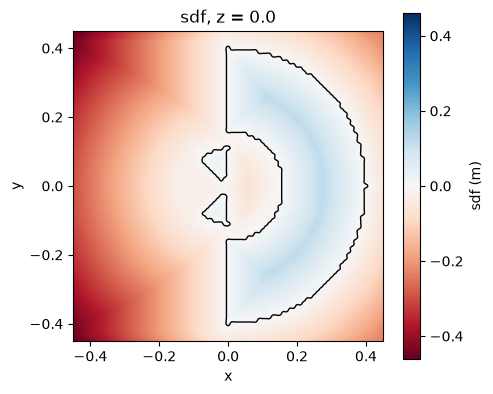

In [12]:
# Slice through the interpolant at z = Z0, finer than the grid.
Z0 = 0.0
s = jnp.linspace(-reach - 0.05, reach + 0.05, 400)
SX, SY = jnp.meshgrid(s, s, indexing="xy")
P2 = jnp.stack([SX.ravel(), SY.ravel(), jnp.full(SX.size, Z0)], -1)
d2 = np.asarray(sdf_vg(P2)[0]).reshape(SX.shape)

v = float(np.abs(d2).max())
plt.figure(figsize=(5, 4.5))
plt.imshow(d2, origin="lower", extent=[s[0], s[-1], s[0], s[-1]], cmap="RdBu", vmin=-v, vmax=v)
plt.colorbar(label="sdf (m)")
plt.contour(SX, SY, d2, [0.0], colors="k", linewidths=1)
plt.title(f"sdf, z = {Z0}"); plt.xlabel("x"); plt.ylabel("y");

In [13]:
rrv.log_points("sdf/slice", np.asarray(P2), values=d2.ravel(), cmap="RdBu", vmin=-v, vmax=v, radius=0.001)

## Trilinear vs. Catmull-Rom

Same grid `D`, same extension outside the grid; only the interpolation differs. Trilinear:
continuous values, piecewise constant gradient (jumps at cell faces), still the true
derivative of the values. Compared on accuracy, gradient consistency, speed, and in a small
NLP: project a point outside the reach set onto it, `min |x - t|^2 s.t. sdf(x) >= 0`
(SLSQP, gradients from JAX).

In [ ]:
from jax.scipy.ndimage import map_coordinates

def sdf_lin(p):
    # Trilinear signed distance (m), shoulder frame; > 0 reachable.
    q = jnp.clip(p, lo, lo + (m - 1) * h)
    dq = p - q
    u = (q - lo) / h
    d = map_coordinates(D, [u[0], u[1], u[2]], order=1, mode="nearest")
    return d - jnp.sqrt(jnp.maximum(dq @ dq, 1e-20))

def make_vg(f, chunk=1 << 18):
    # Batched value and gradient of f at (N, 3) points, in chunks.
    vg = jax.jit(jax.vmap(jax.value_and_grad(f)))
    def run(P):
        out = [vg(P[k:k + chunk]) for k in range(0, P.shape[0], chunk)]
        return jnp.concatenate([o[0] for o in out]), jnp.concatenate([o[1] for o in out])
    return run

interps = {"catmull-rom": (sdf, make_vg(sdf)), "trilinear": (sdf_lin, make_vg(sdf_lin))}

In [ ]:
P = jax.random.uniform(jax.random.PRNGKey(1), (20_000, 3), minval=-reach - 0.1, maxval=reach + 0.1)
near = jnp.abs(sdf_vg(verts)[0]) < 2 * h                  # vertices near the boundary
eps = 1e-4
for name, (f, vg) in interps.items():
    jax.block_until_ready(vg(verts))                      # compile
    t0 = time.perf_counter(); dv, gv = jax.block_until_ready(vg(verts)); t = time.perf_counter() - t0
    d, g = vg(P)
    fd = jnp.stack([(vg(P + eps * e)[0] - vg(P - eps * e)[0]) / (2 * eps) for e in jnp.eye(3)], -1)
    err = jnp.abs(g - fd).max(-1)
    gn = np.asarray(jnp.linalg.norm(gv[near], axis=-1))
    print(f"{name:12s} {1e6 * t / N:6.3f} us/pt | |grad - fd| median {float(jnp.median(err)):.1e}, "
          f"95% {float(jnp.percentile(err, 95)):.1e} | |grad| near boundary median {np.median(gn):.2f} "
          f"[{np.percentile(gn, 5):.2f}, {np.percentile(gn, 95):.2f}]")

d_cr, d_li = interps["catmull-rom"][1](P)[0], interps["trilinear"][1](P)[0]
print(f"value difference: median {float(jnp.median(jnp.abs(d_cr - d_li))) * 1e3:.2f} mm, "
      f"max {float(jnp.abs(d_cr - d_li).max()) * 1e3:.2f} mm")

In [ ]:
# Value and x-gradient along a line through the boundary (y = 0, z = Z0).
xs = jnp.linspace(0.30, 0.45, 600)
line = jnp.stack([xs, jnp.zeros_like(xs), jnp.full_like(xs, Z0)], -1)
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
for name, (f, vg) in interps.items():
    d, g = vg(line)
    ax[0].plot(xs, d, label=name); ax[1].plot(xs, g[:, 0], label=name)
ax[0].axhline(0, color="k", lw=0.5); ax[0].set_title("sdf"); ax[0].set_xlabel("x")
ax[1].set_title("d sdf / dx"); ax[1].set_xlabel("x"); ax[1].legend();

In [ ]:
# Small NLP: project points outside the reach set onto it.
from scipy.optimize import minimize

key = jax.random.PRNGKey(2)
T = jax.random.uniform(key, (4000, 3), minval=-reach, maxval=reach)
T = np.asarray(T[sdf_vg(T)[0] < -0.02][:100], np.float64)   # targets at least 2 cm outside
print(f"{len(T)} targets")

for name, (f, _) in interps.items():
    fv, fg = jax.jit(f), jax.jit(jax.grad(f))
    con = dict(type="ineq", fun=lambda x: np.atleast_1d(np.float64(fv(jnp.asarray(x, jnp.float32)))),
               jac=lambda x: np.asarray(fg(jnp.asarray(x, jnp.float32)), np.float64)[None])
    ok, nit, viol, t0 = [], [], [], time.perf_counter()
    for t in T:
        res = minimize(lambda x: np.sum((x - t) ** 2), t, jac=lambda x: 2 * (x - t),
                       method="SLSQP", constraints=[con], options=dict(maxiter=100, ftol=1e-10))
        ok.append(res.success); nit.append(res.nit); viol.append(max(0.0, -float(con["fun"](res.x)[0])))
    dt = time.perf_counter() - t0
    print(f"{name:12s} success {np.mean(ok):.2f} | iterations median {np.median(nit):.0f}, "
          f"max {np.max(nit)} | final violation max {np.max(viol) * 1e3:.3f} mm | {1e3 * dt / len(T):.1f} ms/solve")

## Resolution sweep

Rebuild the signed distance at several voxel sizes and compare both interpolations against
**exact** membership (IK + the enabled filters) at random points, and in the projection NLP.

Findings (2026-10-09, coxa +-90 deg, both filters):
- Wrong signs only within ~h/2..h of the zero level: the error is linear in h.
- The zero level sits slightly *outside* the true boundary: projections land ~h/2 outside.
  Random points with sdf > h/2 were all truly reachable, but projections constrained to
  sdf >= h/2 only ~75%; with sdf >= h all of them (1 cm / 5 mm / 2 mm). Use the
  constraint `sdf(x) >= h`.
- Catmull-Rom: ~17 iterations at every h. Trilinear: 42 -> 59 -> 76 iterations from 1 cm to
  2 mm (more cells, more gradient jumps).
- Evaluation per point is the same at every h for local queries (as in an NLP); random
  queries over a large grid are slower only from cache misses (274 MB at 2 mm).

In [ ]:
def reachable(foot):
    # Exact membership: some IK branch passes the enabled filters.
    ok, th = leg.ik_from_foot(foot)
    if USE_LIMITS:
        ok = ok & candidates.in_limits(th, leg.limits)
    if FILTER_BODY:
        ok = ok & ~jnp.all(jnp.abs(body.inverse().apply(foot) - body_center) <= body_half)
    return ok.any()

reach_b = jax.jit(jax.vmap(reachable))

def build_sdf(res, pad=PAD, chunk=1 << 20):
    # Grid mask (chunked IK), distance transform, and both interpolants at voxel size res.
    n_ = int(round(2 * reach / res)) + 1
    ax = np.linspace(-reach, reach, n_); h_ = float(ax[1] - ax[0])
    t0 = time.perf_counter()
    mask_ = np.zeros(n_ ** 3, bool)
    for k in range(0, n_ ** 3, chunk):
        idx = np.arange(k, min(k + chunk, n_ ** 3))
        ijk = np.stack(np.unravel_index(idx, (n_, n_, n_)), -1)
        mask_[idx] = np.asarray(reach_b(jnp.asarray(ax[ijk], jnp.float32)))
    t_ik = time.perf_counter() - t0
    t0 = time.perf_counter()
    mask_ = np.pad(mask_.reshape(n_, n_, n_), pad)
    D_ = np.where(mask_, distance_transform_edt(mask_) - 0.5, -(distance_transform_edt(~mask_) - 0.5)) * h_
    D_ = jnp.asarray(D_, jnp.float32)
    t_edt = time.perf_counter() - t0
    m_, lo_ = D_.shape[0], float(ax[0]) - pad * h_

    def cr(p):
        q = jnp.clip(p, lo_ + h_, lo_ + (m_ - 3) * h_); dq = p - q
        u = (q - lo_) / h_; i = jnp.floor(u).astype(jnp.int32); t = u - i
        ix = i[:, None] + jnp.arange(-1, 3)
        patch = D_[ix[0][:, None, None], ix[1][None, :, None], ix[2][None, None, :]]
        return (jnp.einsum("ijk,i,j,k->", patch, _cr_weights(t[0]), _cr_weights(t[1]), _cr_weights(t[2]))
                - jnp.sqrt(jnp.maximum(dq @ dq, 1e-20)))

    def lin(p):
        q = jnp.clip(p, lo_, lo_ + (m_ - 1) * h_); dq = p - q; u = (q - lo_) / h_
        return (map_coordinates(D_, [u[0], u[1], u[2]], order=1, mode="nearest")
                - jnp.sqrt(jnp.maximum(dq @ dq, 1e-20)))

    return dict(n=n_, h=h_, nbytes=D_.nbytes, t_ik=t_ik, t_edt=t_edt,
                fns={"catmull-rom": cr, "trilinear": lin})

In [ ]:
RESOLUTIONS = (0.01, 0.005, 0.002)
N_TARGETS = 100

grids = {res: build_sdf(res) for res in RESOLUTIONS}
for res, g in grids.items():
    print(f"{res * 1e3:4g} mm: {g['n']}^3 = {g['n'] ** 3:>11,} vertices | IK {g['t_ik']:5.1f} s | "
          f"distance transform {g['t_edt']:5.1f} s | grid {g['nbytes'] / 1e6:6.1f} MB")

# Test data, fixed across resolutions: random points with exact membership; projection
# targets at least 2 cm outside (by the finest grid).
Pt = jax.random.uniform(jax.random.PRNGKey(1), (400_000, 3), minval=-reach - 0.02, maxval=reach + 0.02)
inside = np.concatenate([np.asarray(reach_b(Pt[k:k + 1 << 20])) for k in range(0, Pt.shape[0], 1 << 20)])
cand = jax.random.uniform(jax.random.PRNGKey(2), (8000, 3), minval=-reach, maxval=reach)
dc = jax.vmap(grids[min(RESOLUTIONS)]["fns"]["catmull-rom"])(cand)
T = np.asarray(cand[(dc < -0.02) & ~reach_b(cand)][:N_TARGETS], np.float64)
print(f"{len(T)} projection targets")

In [ ]:
def project(f, t, margin):
    # SLSQP: min |x - t|^2 s.t. f(x) >= margin.
    fv, fg = jax.jit(f), jax.jit(jax.grad(f))
    con = dict(type="ineq",
               fun=lambda x: np.atleast_1d(np.float64(fv(jnp.asarray(x, jnp.float32))) - margin),
               jac=lambda x: np.asarray(fg(jnp.asarray(x, jnp.float32)), np.float64)[None])
    return minimize(lambda x: np.sum((x - t) ** 2), t, jac=lambda x: 2 * (x - t), method="SLSQP",
                    constraints=[con], options=dict(maxiter=100, ftol=1e-10))

rows = []
for res, g in grids.items():
    for name, f in g["fns"].items():
        d = np.asarray(jax.vmap(f)(Pt))
        wrong = (d > 0) != inside
        row = dict(res_mm=res * 1e3, interp=name, sign_wrong=wrong.mean(),
                   max_d_wrong_mm=1e3 * np.abs(d[wrong]).max() if wrong.any() else 0.0,
                   above_half_h_reachable=inside[d > g["h"] / 2].mean())
        for margin, tag in ((0.0, "m0"), (g["h"] / 2, "mh2")):
            t0 = time.perf_counter()
            res_ = [project(f, t, margin) for t in T]
            row[f"{tag}_success"] = np.mean([r.success for r in res_])
            row[f"{tag}_iters"] = np.median([r.nit for r in res_])
            row[f"{tag}_truly_reachable"] = np.asarray(reach_b(jnp.asarray(np.stack([r.x for r in res_]), jnp.float32))).mean()
            row[f"{tag}_ms"] = 1e3 * (time.perf_counter() - t0) / len(T)
        rows.append(row)

print(f"{'res':>5} {'interp':>12} | {'sign wrong':>10} {'max|d|':>7} {'d>h/2 reach':>11} | "
      f"{'margin 0: ok':>12} {'iters':>5} {'reach':>5} | {'margin h/2: ok':>14} {'iters':>5} {'reach':>5}")
for r in rows:
    print(f"{r['res_mm']:4g}mm {r['interp']:>12} | {r['sign_wrong']:10.4f} {r['max_d_wrong_mm']:6.1f}mm "
          f"{r['above_half_h_reachable']:11.3f} | {r['m0_success']:12.2f} {r['m0_iters']:5.0f} "
          f"{r['m0_truly_reachable']:5.2f} | {r['mh2_success']:14.2f} {r['mh2_iters']:5.0f} {r['mh2_truly_reachable']:5.2f}")

In [ ]:
# Evaluation time per point: random points over the whole box vs. local ones (within ~1 cm,
# as an NLP's queries). Slower random queries on big grids are cache misses.
loc = jnp.array([0.25, 0.0, -0.1]) + 0.01 * jax.random.normal(jax.random.PRNGKey(3), Pt.shape)
for res, g in grids.items():
    for name, f in g["fns"].items():
        vg = jax.jit(jax.vmap(jax.value_and_grad(f)))
        cells = []
        for lab, Q in (("random", Pt), ("local", loc)):
            jax.block_until_ready(vg(Q))
            t0 = time.perf_counter()
            for _ in range(3):
                jax.block_until_ready(vg(Q))
            cells.append(f"{lab} {1e6 * (time.perf_counter() - t0) / 3 / Q.shape[0]:.3f}")
        print(f"{res * 1e3:4g} mm ({g['nbytes'] / 1e6:5.1f} MB) {name:12s} us/pt: " + " | ".join(cells))